In [1]:
# Repository bootstrap: make local packages importable from any notebook working directory.
from pathlib import Path
import sys
_HERE = Path.cwd().resolve()
_REPO_ROOT = next((p for p in (_HERE, *_HERE.parents) if (p / 'publication_reconstruction').is_dir() and (p / 'data').is_dir()), None)
if _REPO_ROOT is None:
    raise RuntimeError('Could not locate repository root from the notebook working directory.')
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))


# Synthetic Hard X-ray Diagnostic Analysis

This notebook demonstrates a reproducible synthetic HXR workflow. The data are not original IR-T1 measurements and do not reconstruct the NaI detector response.

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().resolve().parents[1]))
import numpy as np
import matplotlib.pyplot as plt
from hard_xray.synthetic import generate_hxr_time_series, generate_hxr_spectrum
from hard_xray.signal_analysis.analysis import power_spectrum, burst_features
from hard_xray.spectrum_analysis.spectrum import hardness_ratio, spectral_tail_feature
from hard_xray.xray_mhd_correlation.correlation import correlation_coefficient, cross_correlation

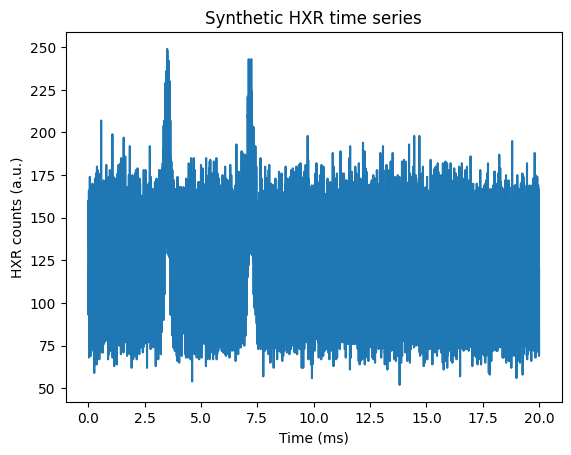

In [3]:
hxr = generate_hxr_time_series(duration_s=0.02, noise_std=0)
plt.figure(); plt.plot(hxr.time_s*1e3,hxr.counts); plt.xlabel("Time (ms)"); plt.ylabel("HXR counts (a.u.)"); plt.title("Synthetic HXR time series"); plt.show()

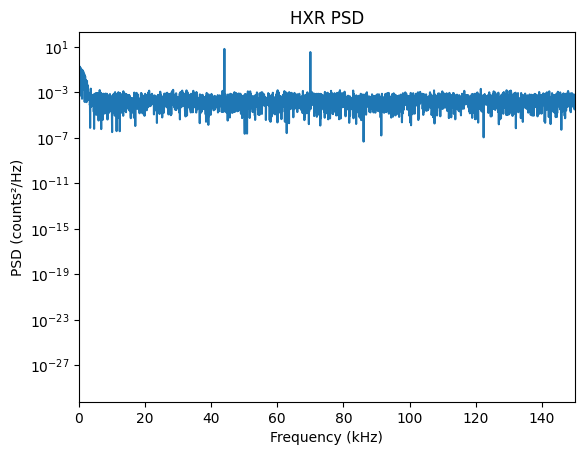

Dominant frequency (Hz): 44000.0


In [4]:
f,p = power_spectrum(hxr.counts,hxr.sampling_frequency_hz)
plt.figure(); plt.semilogy(f/1e3,p); plt.xlabel("Frequency (kHz)"); plt.ylabel("PSD (counts²/Hz)"); plt.title("HXR PSD"); plt.xlim(0,150); plt.show()
print("Dominant frequency (Hz):", f[1:][np.argmax(p[1:])])

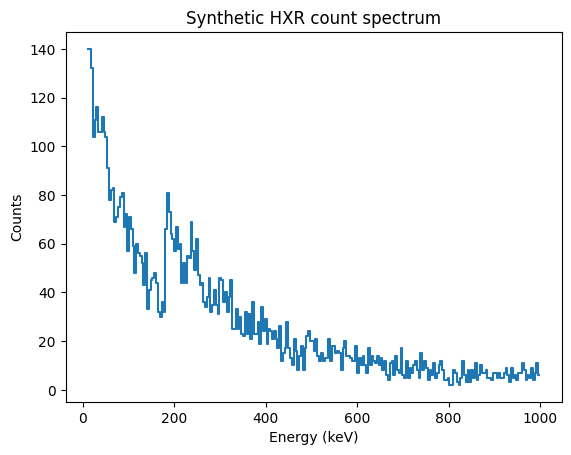

Hardness ratio: 1.2657342657342658
Tail: {'threshold_keV': 180.0, 'tail_counts': 3945, 'tail_fraction': 0.5572033898305084}


In [5]:
spec = generate_hxr_spectrum(seed=42)
plt.figure(); plt.step(spec.energy_keV,spec.counts,where="mid"); plt.xlabel("Energy (keV)"); plt.ylabel("Counts"); plt.title("Synthetic HXR count spectrum"); plt.show()
print("Hardness ratio:", hardness_ratio(spec.energy_keV,spec.counts,(30,120),(250,700)))
print("Tail:", spectral_tail_feature(spec.energy_keV,spec.counts,180))

Zero-lag correlation: 0.6617303595797217


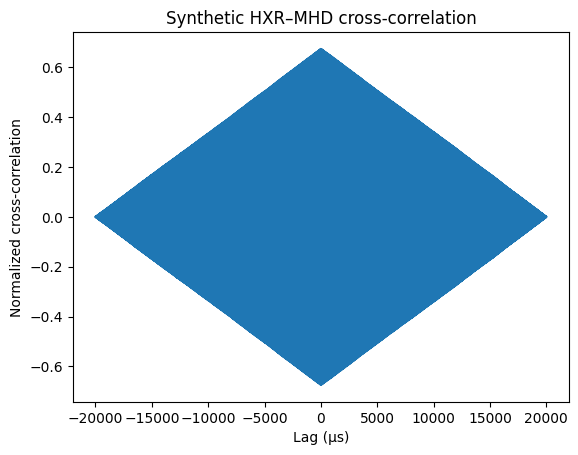

In [6]:
t=hxr.time_s
mhd=np.sin(2*np.pi*44_000*t+0.2)
lags,corr=cross_correlation(hxr.counts,mhd,hxr.sampling_frequency_hz)
print("Zero-lag correlation:", correlation_coefficient(hxr.counts,mhd))
plt.figure(); plt.plot(lags*1e6,corr); plt.xlabel("Lag (µs)"); plt.ylabel("Normalized cross-correlation"); plt.title("Synthetic HXR–MHD cross-correlation"); plt.show()

## Interpretation and limitations

The workflow demonstrates temporal HXR analysis, count-spectrum feature extraction, and a focused HXR–MHD comparison. The high-energy tail is an observable synthetic feature; it is not a direct reconstruction of an electron distribution function. The published IR-T1 value near 992.93 keV is treated as contextual literature information rather than a synthetic ground truth.